Link to video:<br>
https://drive.google.com/drive/folders/1YRycHeLMnhoZ4Q3gbEqR975KiRxtC2qM?usp=sharing

Link to streamlit app:<br>
https://appapppy-6zxuqoew8rarbwxyjmwhyw.streamlit.app/

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder 
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, ConfusionMatrixDisplay, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

c:\Users\User\miniconda3\envs\model_deployment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


• Workflow: Lakukan analisis korelasi, penanganan missing values, feature engineering, dan
pembagian data train-test (80:20).<br>
• Modeling: Bangun dan bandingkan minimal tiga algoritma untuk masing-masing tugas
(Klasifikasi & Regresi).<br>
• Dokumentasi: Gunakan Markdown untuk menjelaskan alasan pemilihan fitur dan interpretasi
hasil metrik evaluasi yang sesuai.<br>
• Indikator Nilai: Performa model (metrik evaluasi) dan kedalaman analisis pada Markdown.

In [2]:
df_data = pd.read_csv("A.csv")
pd.set_option('display.max_columns', None)
df_data.head()


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,4,2,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,3,4,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,5,1,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,3,1,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,2,5,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [3]:
df_target = pd.read_csv("A_targets.csv")
df_target.tail()

,Student_ID,placement_status,salary_lpa
4995,4996,Placed,19.35
4996,4997,Not Placed,0.00
4997,4998,Placed,19.13
4998,4999,Placed,16.53
4999,5000,Placed,20.00


In [4]:
df = pd.merge(df_data, df_target, on='Student_ID')
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,4,2,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,3,4,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,5,1,4,6,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,3,1,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,2,5,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [5]:
train, test = train_test_split(df, test_size = 0.2, random_state = 42)

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 4227 to 860
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4000 non-null   int64  
 1   gender                       4000 non-null   object 
 2   branch                       4000 non-null   object 
 3   cgpa                         4000 non-null   float64
 4   tenth_percentage             4000 non-null   float64
 5   twelfth_percentage           4000 non-null   float64
 6   backlogs                     4000 non-null   int64  
 7   study_hours_per_day          4000 non-null   float64
 8   attendance_percentage        4000 non-null   float64
 9   projects_completed           4000 non-null   int64  
 10  internships_completed        4000 non-null   int64  
 11  coding_skill_rating          4000 non-null   int64  
 12  communication_skill_rating   4000 non-null   int64  
 13  aptitude_skill_rating

In [7]:
train.duplicated().sum()

np.int64(0)

In [8]:
train.isna().sum()

Student_ID                       0
gender                           0
branch                           0
cgpa                             0
tenth_percentage                 0
twelfth_percentage               0
backlogs                         0
study_hours_per_day              0
attendance_percentage            0
projects_completed               0
internships_completed            0
coding_skill_rating              0
communication_skill_rating       0
aptitude_skill_rating            0
hackathons_participated          0
certifications_count             0
sleep_hours                      0
stress_level                     0
part_time_job                    0
family_income_level              0
city_tier                        0
internet_access                  0
extracurricular_involvement    800
placement_status                 0
salary_lpa                       0
dtype: int64

There is 800 missing value on column 'extracurricular_involvement' which about 20% on train we make new value called None.

In [9]:
datasets = [train, test]

for df in datasets:
    df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna('None')

train.isna().sum()

Student_ID                     0
gender                         0
branch                         0
cgpa                           0
tenth_percentage               0
twelfth_percentage             0
backlogs                       0
study_hours_per_day            0
attendance_percentage          0
projects_completed             0
internships_completed          0
coding_skill_rating            0
communication_skill_rating     0
aptitude_skill_rating          0
hackathons_participated        0
certifications_count           0
sleep_hours                    0
stress_level                   0
part_time_job                  0
family_income_level            0
city_tier                      0
internet_access                0
extracurricular_involvement    0
placement_status               0
salary_lpa                     0
dtype: int64

In [10]:
# checking for inconsistent value on categorical column
cat_col = train.select_dtypes('object').columns

for col in cat_col:
    print(f"Unique values in {col}:")
    print(train[col].value_counts())
    print("-" * 30)

Unique values in gender:
gender
Male      2385
Female    1615
Name: count, dtype: int64
------------------------------
Unique values in branch:
branch
CSE    1230
ECE    1034
IT      771
ME      604
CE      361
Name: count, dtype: int64
------------------------------
Unique values in part_time_job:
part_time_job
No     3197
Yes     803
Name: count, dtype: int64
------------------------------
Unique values in family_income_level:
family_income_level
Medium    1983
Low       1215
High       802
Name: count, dtype: int64
------------------------------
Unique values in city_tier:
city_tier
Tier 2    1626
Tier 3    1234
Tier 1    1140
Name: count, dtype: int64
------------------------------
Unique values in internet_access:
internet_access
Yes    3569
No      431
Name: count, dtype: int64
------------------------------
Unique values in extracurricular_involvement:
extracurricular_involvement
Low       1205
Medium    1175
High       820
None       800
Name: count, dtype: int64
--------------

In [11]:
# checking distribution for numerical column (except student_id)
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Student_ID', errors='ignore')
train[num_cols].describe()

,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000
mean,8.282410,74.523525,74.555225,0.335000,4.043850,72.048425,5.533500,2.139500,3.728750,3.017250,4.11775,3.700000,2.835250,6.95125,6.029250,13.898160
std,0.997413,10.198732,10.146399,0.598218,1.969669,7.764477,2.039833,1.147767,1.270857,1.405328,0.71310,1.594564,1.775076,1.14302,2.856998,6.248902
min,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.00000,0.000000,0.000000,4.00000,1.000000,0.000000
25%,7.620000,67.500000,67.675000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.00000,3.000000,2.000000,6.20000,4.000000,12.547500
50%,8.310000,74.700000,74.800000,0.000000,4.000000,72.100000,6.000000,2.000000,4.000000,3.000000,4.00000,4.000000,3.000000,7.00000,6.000000,15.740000
75%,9.000000,81.900000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.00000,5.000000,4.000000,7.80000,9.000000,18.340000
max,10.000000,100.000000,100.000000,4.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.00000,6.000000,9.000000,9.00000,10.000000,20.000000


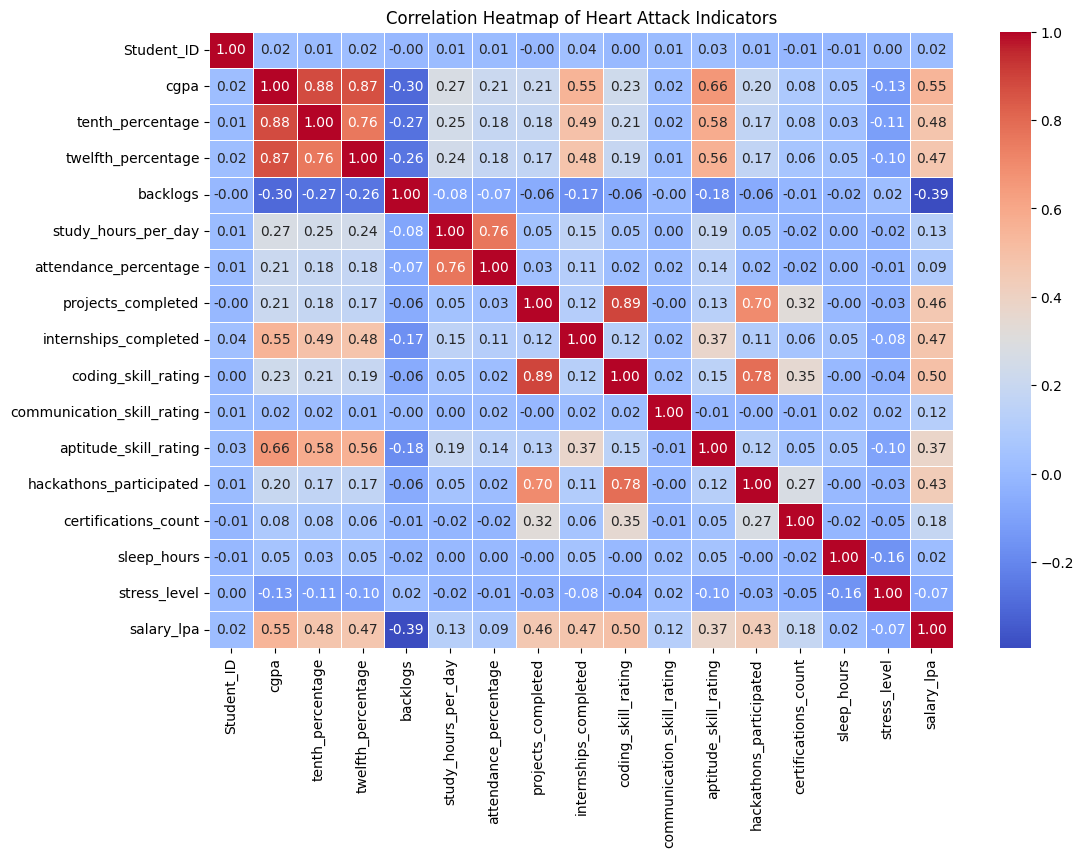

In [12]:
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Heart Attack Indicators')
plt.show()

What I found interesting from this heatmap:
1. CGPA has a strong correlation with tenth_percentage and twelfth_percentage. Therefore, I will drop the 10th and 12th-grade columns to reduce redundancy in the model. Additionally, hiring companies typically prioritize a candidate's university CGPA rather than their high school grades.

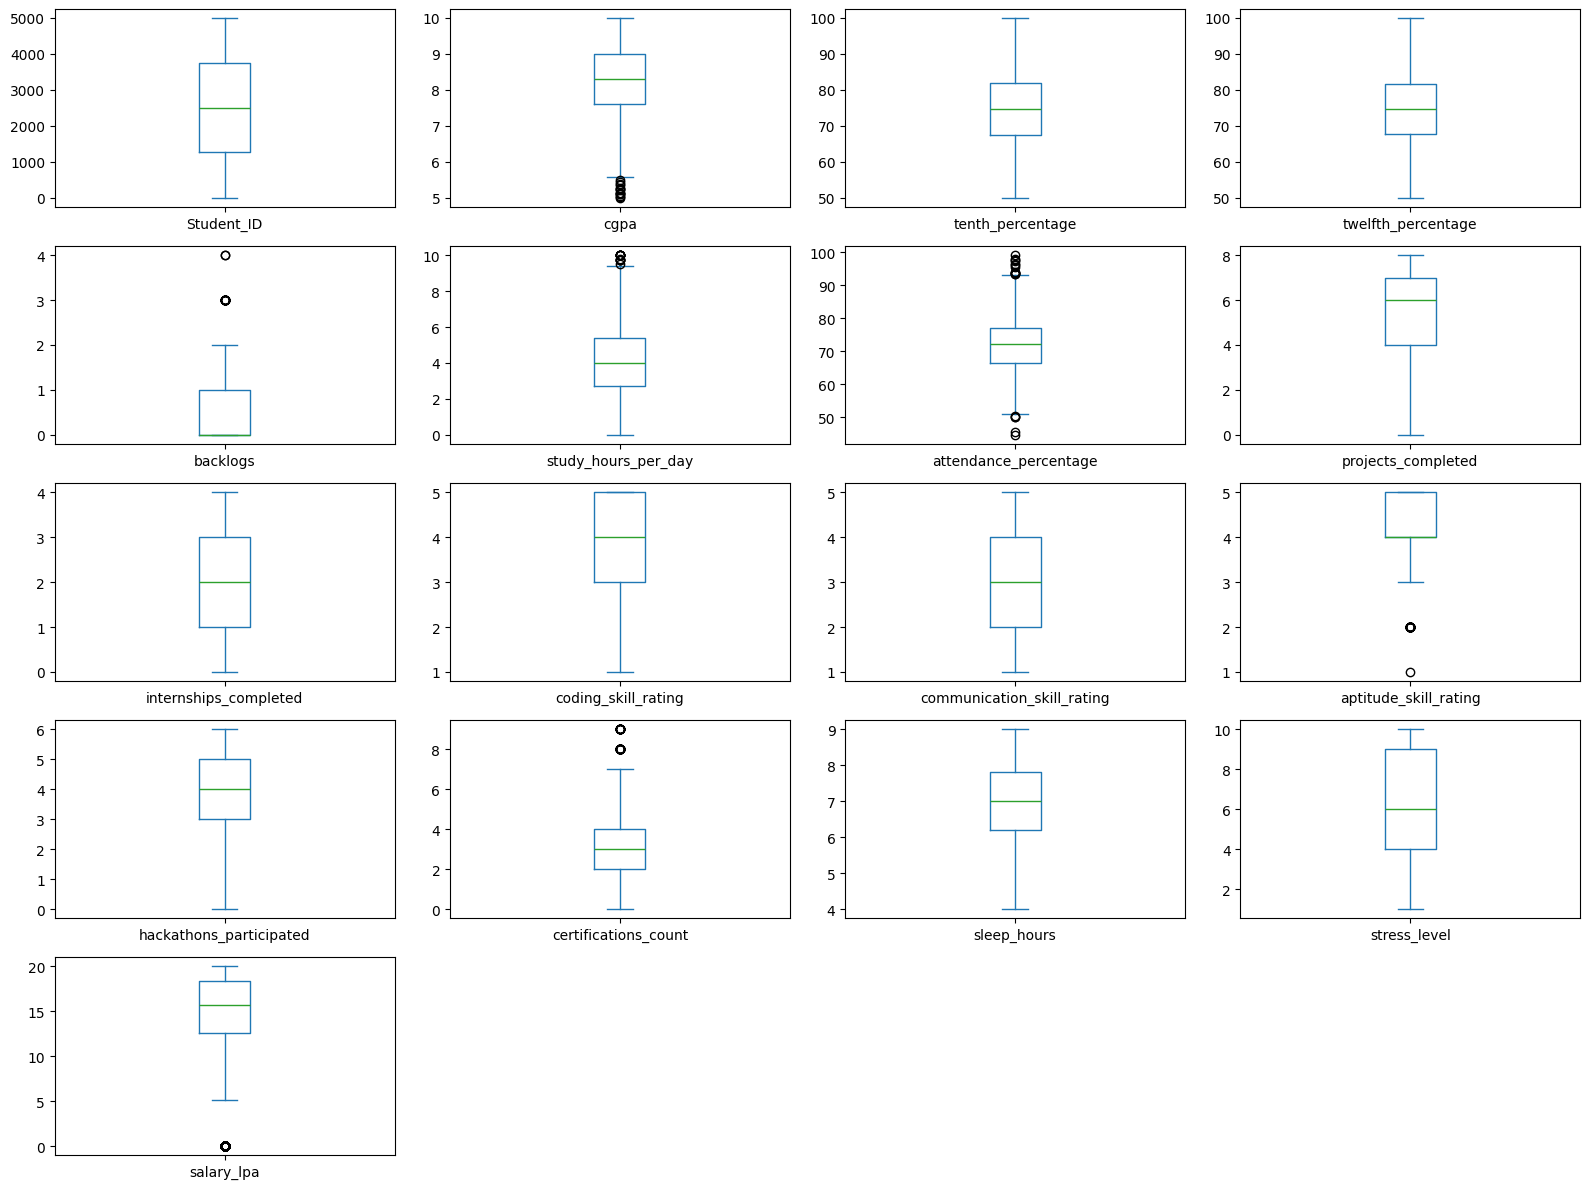

In [13]:
num = train.select_dtypes(exclude=['object'])
num = num.drop('Student_ID', errors='ignore')

num.plot(kind='box', subplots=True, layout=(-1, 4), figsize=(16, 12))

plt.tight_layout()
plt.show()

There is no outlier that needs to be capped

In [14]:
# Define the order manually for target classification
mapping = {'Not Placed': 0, 'Placed': 1}

# Apply to the column
train['placement_status'] = train['placement_status'].map(mapping)
test['placement_status'] = test['placement_status'].map(mapping)

cols_to_drop = ['Student_ID', 'placement_status', 'salary_lpa', 'tenth_percentage', 'twelfth_percentage']

x_train = train.drop(columns=cols_to_drop)
x_test = test.drop(columns=cols_to_drop)

y_train = train['placement_status']
y_test = test['placement_status']

Student_ID: Dibuang karena hanya ID unik (noise) yang tidak punya pola prediksi.

placement_status & salary_lpa: Dibuang karena ini adalah Target Variable; jika dimasukkan ke training, model akan "curang" karena sudah tahu jawabannya (Data Leakage).

10th/12th percentage: kurang relevan dibandingkan performa universitas (CGPA) saat ini untuk memprediksi hasil akhir.

In [ ]:
# Nominal categories (0, 1, 2...) that need OneHot encoding
onehot_features = ['gender', 'branch', 'part_time_job', 'internet_access']

# Continuous/Numeric columns that need scaling
numeric_features = [
    'cgpa', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 
    'projects_completed', 'internships_completed', 'coding_skill_rating', 
    'communication_skill_rating', 'aptitude_skill_rating', 
    'hackathons_participated', 'certifications_count', 'sleep_hours', 'stress_level'
]

# Ordinal Column
ordinal_features = ['family_income_level', 'city_tier', 'extracurricular_involvement']

onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

robust_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        ['Low', 'Medium', 'High'], # For family_income_level
        ['Tier 3', 'Tier 2', 'Tier 1'], # For city_tier
        ['None', 'Low', 'Medium', 'High']  # For extracurricular_involvement
    ], handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('onehot', onehot_pipeline, onehot_features),
    ('ordinal', ordinal_pipeline, ordinal_features),
    ('num', robust_pipeline, numeric_features)
], remainder='drop') # drop 'target' if it's still in X, otherwise use 'passthrough'

In [16]:
models_clf = {
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))]),
    'LightGBM': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LGBMClassifier(random_state=42, verbose=-1))]),
    'XGBoost': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))])
}

In [17]:
# Classification 
for name, pipeline in models_clf.items():
    pipeline.fit(x_train, y_train)
    y_pred_test = pipeline.predict(x_test)
    
    print(f"\n[{name}] Classification Report (Test Set):")
    print(classification_report(y_test, y_pred_test, digits=4))



[Random Forest] Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.6026    0.3406    0.4352       138
           1     0.9013    0.9640    0.9316       862

    accuracy                         0.8780      1000
   macro avg     0.7519    0.6523    0.6834      1000
weighted avg     0.8601    0.8780    0.8631      1000


[LightGBM] Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.5421    0.4203    0.4735       138
           1     0.9104    0.9432    0.9265       862

    accuracy                         0.8710      1000
   macro avg     0.7262    0.6817    0.7000      1000
weighted avg     0.8596    0.8710    0.8640      1000


[XGBoost] Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.5082    0.4493    0.4769       138
           1     0.9134    0.9304    0.9218       862

    accuracy                         0.8

In [18]:
# Regression
models_reg = {
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))]),  
    'LightGBM': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LGBMRegressor(random_state=42, verbose=-1))]),
    'XGBoost': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', XGBRegressor(random_state=42))])
}

In [19]:
# Filter data first

placed_mask = train['placement_status'] == 1
x_train_reg = train[placed_mask].drop(columns=cols_to_drop)
y_train_reg = train.loc[placed_mask, 'salary_lpa']

placed_mask_test = test['placement_status'] == 1
x_test_reg = test[placed_mask_test].drop(columns=cols_to_drop)
y_test_reg = test.loc[placed_mask_test, 'salary_lpa']

for name, pipeline in models_reg.items():
    pipeline.fit(x_train_reg, y_train_reg)
    preds_test = pipeline.predict(x_test_reg)
    
    mae = mean_absolute_error(y_test_reg, preds_test)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds_test))
    r2 = r2_score(y_test_reg, preds_test)
    
    print(f"[{name}] MAE: {mae:.4f} LPA | RMSE: {rmse:.4f} LPA | R2: {r2:.4f}")

[Random Forest] MAE: 1.1789 LPA | RMSE: 1.4860 LPA | R2: 0.7638
[LightGBM] MAE: 1.1030 LPA | RMSE: 1.4193 LPA | R2: 0.7845
[XGBoost] MAE: 1.1895 LPA | RMSE: 1.5158 LPA | R2: 0.7542


Because of the imbalance in the dataset, I use class weights to force the algorithm to pay equal attention to the minority class by heavily penalizing any mistakes made on it

In [20]:
xgboost_ratio = (y_train == 0).sum() / (y_train == 1).sum()
models_clf = {
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))]),
    'LightGBM': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))]),
    'XGBoost': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', XGBClassifier(random_state=42, scale_pos_weight=xgboost_ratio, eval_metric='logloss'))])
}

In [21]:
# Classification 
for name, pipeline in models_clf.items():
    pipeline.fit(x_train, y_train)
    y_pred_test = pipeline.predict(x_test)
    
    print(f"\n[{name}] Classification Report (Test Set):")
    print(classification_report(y_test, y_pred_test, digits=4))



[Random Forest] Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.6552    0.2754    0.3878       138
           1     0.8938    0.9768    0.9335       862

    accuracy                         0.8800      1000
   macro avg     0.7745    0.6261    0.6606      1000
weighted avg     0.8609    0.8800    0.8582      1000


[LightGBM] Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.4356    0.6377    0.5176       138
           1     0.9373    0.8677    0.9012       862

    accuracy                         0.8360      1000
   macro avg     0.6865    0.7527    0.7094      1000
weighted avg     0.8681    0.8360    0.8483      1000


[XGBoost] Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.4649    0.6232    0.5325       138
           1     0.9362    0.8852    0.9100       862

    accuracy                         0.8

Untuk Classifier, model paling bagus adalah XGBoost.
- F1-score tertinggi sebesar 0.7212. Dimana ini indikator terbaik untuk imbalanced data karena memberikan bobot yang sama untuk setiap kelas.
- XGBoost memiliki F-1 untuk Class 0 sebesar 0.5325, lebih tinggi dibanding LightGBM (0.5176) dan jauh melampaui Random Forest (0.3878).

Selain F-1 score, kita juga melihat recall karena recall memberi tahu seberapa banyak class 0 yang berhasil dideteksi oleh model. Disini Recall XGBoost hampir mendekati LightGBM

In [22]:
# Regression
# Filter data first
placed_mask_test = test['placement_status'] == 1
x_test_reg = test[placed_mask_test].drop(columns=cols_to_drop)
y_test_reg = test.loc[placed_mask_test, 'salary_lpa']

for name, pipeline in models_reg.items():
    pipeline.fit(x_train_reg, y_train_reg)
    preds_test = pipeline.predict(x_test_reg)
    
    mae = mean_absolute_error(y_test_reg, preds_test)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds_test))
    r2 = r2_score(y_test_reg, preds_test)
    
    print(f"[{name}] MAE: {mae:.4f} LPA | RMSE: {rmse:.4f} LPA | R2: {r2:.4f}")

[Random Forest] MAE: 1.1789 LPA | RMSE: 1.4860 LPA | R2: 0.7638
[LightGBM] MAE: 1.1030 LPA | RMSE: 1.4193 LPA | R2: 0.7845
[XGBoost] MAE: 1.1895 LPA | RMSE: 1.5158 LPA | R2: 0.7542


Untuk Regression, model paling bagus adalah LightGBM.
- MAE (1.1030) & RMSE (1.4193) Terendah. LightGBM memiliki nilai error paling kecil. Ini berarti prediksi gaji (LPA) yang dihasilkan oleh LightGBM paling mendekati nilai aslinya dibandingkan Random Forest dan XGBoost.
- R2 Score (0.7845) Tertinggi. Nilai R2 yang paling mendekati 1 menunjukkan bahwa LightGBM mampu menjelaskan variansi data sebesar 78.45%, lebih tinggi daripada dua model lainnya.